### Import Libraries

In [25]:
import pandas as pd
import numpy as np

import nltk
import string

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### Download NLTK Resources

In [26]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Load Dataset

In [27]:
df = pd.read_csv(
    "coretech_feedback.csv"
)

df.head()

,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment
0,1001,TechVision,AI,Excellent AI solution and very accurate predic...,5,Positive
1,1002,FinTech Pro,Cloud,Cloud deployment was smooth and efficient,5,Positive
2,1003,DataWorks,Analytics,Analytics dashboard provides valuable insights,5,Positive
3,1004,CloudNova,Cloud,Cloud performance exceeded expectations,5,Positive
4,1005,Retail Connect,Support,Customer support responded quickly and profess...,5,Positive


### Dataset Overview

In [28]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Feedback_ID    45 non-null     int64 
 1   Client_Name    45 non-null     object
 2   Service        45 non-null     object
 3   Feedback_Text  45 non-null     object
 4   Rating         45 non-null     int64 
 5   Sentiment      45 non-null     object
dtypes: int64(2), object(4)
memory usage: 2.2+ KB
None
       Feedback_ID     Rating
count    45.000000  45.000000
mean   1023.000000   4.466667
std      13.133926   0.967659
min    1001.000000   2.000000
25%    1012.000000   4.000000
50%    1023.000000   5.000000
75%    1034.000000   5.000000
max    1045.000000   5.000000


### Sentiment Distribution Chart
Save graph as PNG:


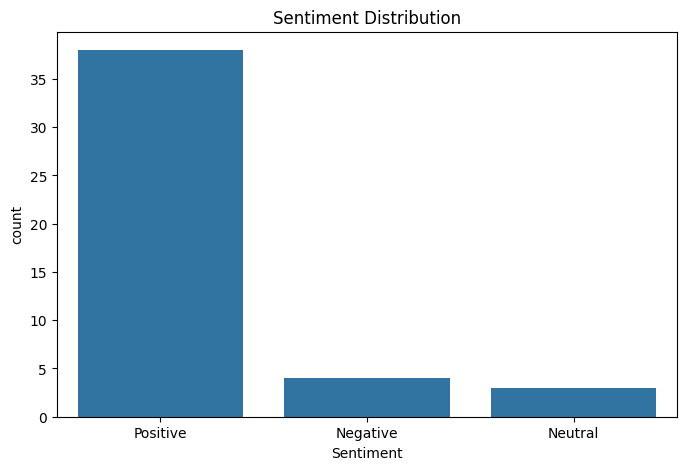

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Sentiment'
)

plt.title(
    'Sentiment Distribution'
)

plt.savefig(
    'sentiment_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Download:

In [30]:
from google.colab import files
files.download("sentiment_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Text Cleaning
- Converts text to lowercase
- Removes punctuation
- Removes special characters

In [31]:
import re
import string

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    return text

df["Clean_Text"] = df["Feedback_Text"].apply(
    clean_text
)

df[
    ["Feedback_Text","Clean_Text"]
].head()

,Feedback_Text,Clean_Text
0,Excellent AI solution and very accurate predic...,excellent ai solution and very accurate predic...
1,Cloud deployment was smooth and efficient,cloud deployment was smooth and efficient
2,Analytics dashboard provides valuable insights,analytics dashboard provides valuable insights
3,Cloud performance exceeded expectations,cloud performance exceeded expectations
4,Customer support responded quickly and profess...,customer support responded quickly and profess...


### Tokenization + Stopword Removal
- Breaks sentences into words
- Removes useless words like:

In [32]:
import nltk
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords

nltk.download('punkt') # Ensure punkt tokenizer data is available
nltk.download('punkt_tab') # Download punkt_tab explicitly

stop_words = set(
    stopwords.words("english")
)

def tokenize_text(text):

    tokens = word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    return tokens

df["Tokens"] = df["Clean_Text"].apply(
    tokenize_text
)

df[
    ["Clean_Text","Tokens"]
].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Clean_Text,Tokens
0,excellent ai solution and very accurate predic...,"[excellent, ai, solution, accurate, predictions]"
1,cloud deployment was smooth and efficient,"[cloud, deployment, smooth, efficient]"
2,analytics dashboard provides valuable insights,"[analytics, dashboard, provides, valuable, ins..."
3,cloud performance exceeded expectations,"[cloud, performance, exceeded, expectations]"
4,customer support responded quickly and profess...,"[customer, support, responded, quickly, profes..."


### Lemmatization
This is more professional than stemming.

Example:
- running -> run
- cars -> car
- predictions -> prediction

In [33]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):

    return [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

df["Lemmatized"] = df["Tokens"].apply(
    lemmatize_tokens
)

df[
    ["Tokens","Lemmatized"]
].head()

,Tokens,Lemmatized
0,"[excellent, ai, solution, accurate, predictions]","[excellent, ai, solution, accurate, prediction]"
1,"[cloud, deployment, smooth, efficient]","[cloud, deployment, smooth, efficient]"
2,"[analytics, dashboard, provides, valuable, ins...","[analytics, dashboard, provides, valuable, ins..."
3,"[cloud, performance, exceeded, expectations]","[cloud, performance, exceeded, expectation]"
4,"[customer, support, responded, quickly, profes...","[customer, support, responded, quickly, profes..."


### Word Cloud

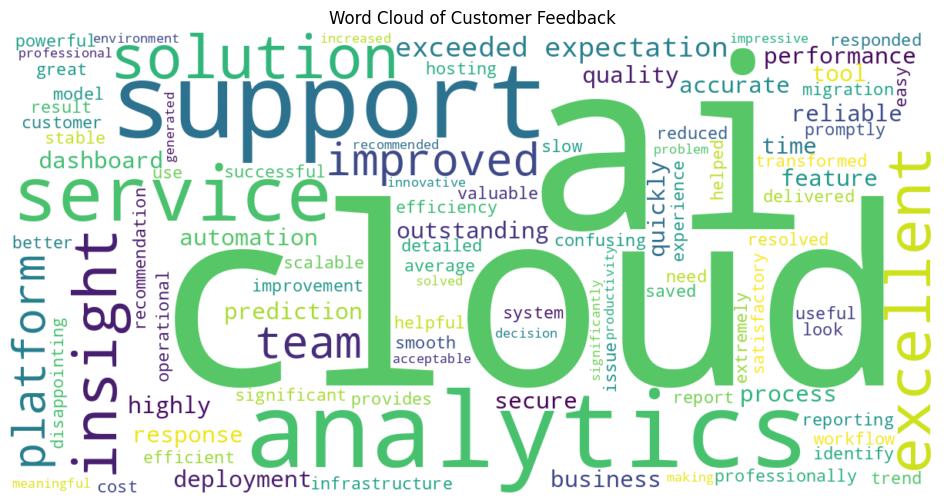

In [35]:
from wordcloud import WordCloud

# Join the lemmatized tokens into a single string for each row, then join all rows into one large text
text = " ".join(
    df["Lemmatized"].apply(lambda x: " ".join(x))
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis("off")

plt.title(
    "Word Cloud of Customer Feedback"
)

plt.savefig(
    "wordcloud.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Download Word Cloud

In [36]:
from google.colab import files

files.download(
    "wordcloud.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Top 20 Most Frequent Words

In [37]:
from collections import Counter

all_words = []

for tokens in df["Lemmatized"]:
    all_words.extend(tokens)

word_counts = Counter(
    all_words
)

top_words = word_counts.most_common(20)

top_df = pd.DataFrame(
    top_words,
    columns=["Word","Frequency"]
)

top_df

,Word,Frequency
0,cloud,12
1,ai,11
2,analytics,11
3,support,11
4,service,5
5,excellent,3
6,solution,3
7,insight,3
8,exceeded,3
9,expectation,3


#### Creating Top Words Graph

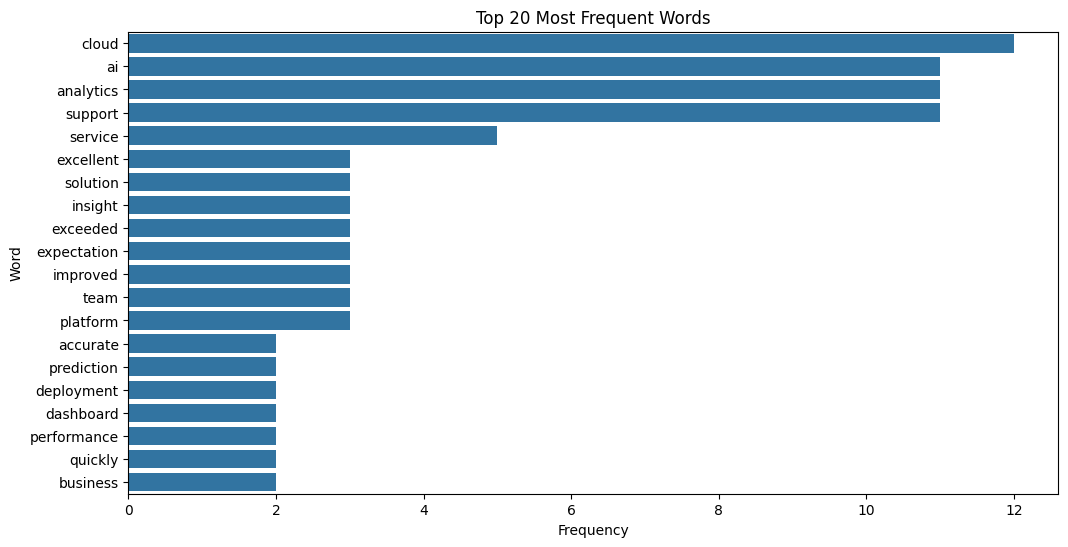

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=top_df
)

plt.title(
    "Top 20 Most Frequent Words"
)

plt.savefig(
    "top_words.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [39]:
# Download
files.download(
    "top_words.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) converts textual data into numerical representations. It assigns higher importance to meaningful words while reducing the influence of commonly occurring terms.

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

# Join the lemmatized tokens back into a single string for each document
X = vectorizer.fit_transform(
    df["Lemmatized"].apply(lambda x: " ".join(x))
)

print(X.shape)

(45, 99)


### Top TF-IDF Keywords

Extra Analysis

In [42]:
feature_names = vectorizer.get_feature_names_out()

scores = X.sum(axis=0).A1

tfidf_df = pd.DataFrame({
    "Word": feature_names,
    "Score": scores
})

tfidf_df = tfidf_df.sort_values(
    by="Score",
    ascending=False
).head(20)

tfidf_df

,Word,Score
8,cloud,4.148742
88,support,3.703728
3,analytics,3.663058
2,ai,3.639110
79,service,2.321139
53,platform,1.620772
23,exceeded,1.619289
25,expectation,1.619289
24,excellent,1.542485
84,solution,1.461899


### TF-IDF Graph

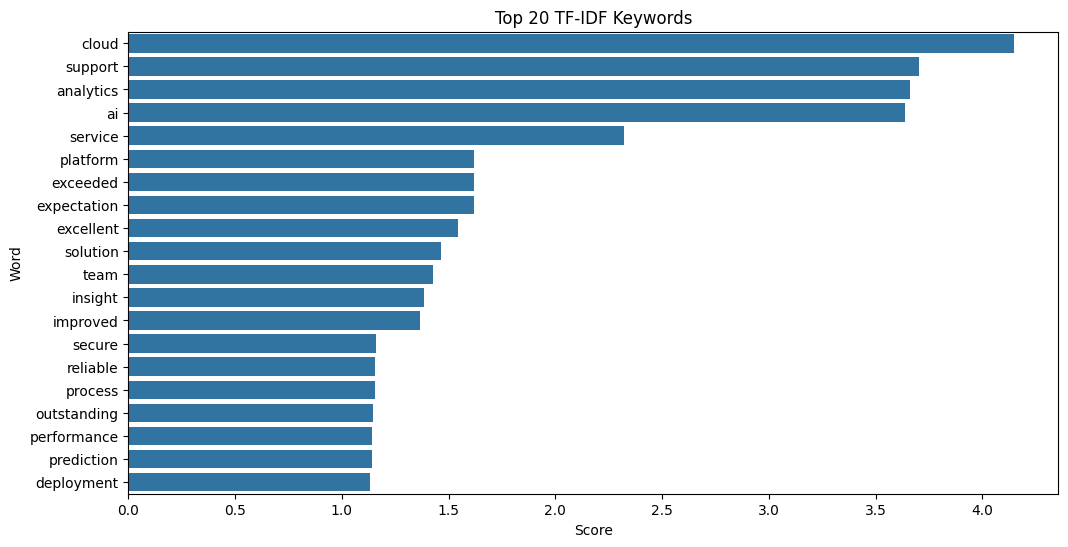

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Score",
    y="Word",
    data=tfidf_df
)

plt.title(
    "Top 20 TF-IDF Keywords"
)

plt.savefig(
    "tfidf_keywords.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [44]:
# Download
files.download(
    "tfidf_keywords.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Train Test Split

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df["Sentiment"],
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(36, 99)
(9, 99)


## Train Naive Bayes

## Why Naive Bayes?

Naive Bayes is a widely used machine learning algorithm for text classification. It is efficient, fast, and performs well on NLP tasks such as sentiment analysis. In this project, TF-IDF features are used as input to train the Naive Bayes classifier for predicting customer sentiment.

In [46]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

MultinomialNB()

## Prediction

In [47]:
predictions = model.predict(
    X_test
)

predictions

array(['Positive', 'Positive', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive'], dtype='<U8')

## Accuracy Score

In [48]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

Accuracy: 88.89 %


## Classification Report

In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.89      1.00      0.94         8

    accuracy                           0.89         9
   macro avg       0.44      0.50      0.47         9
weighted avg       0.79      0.89      0.84         9



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

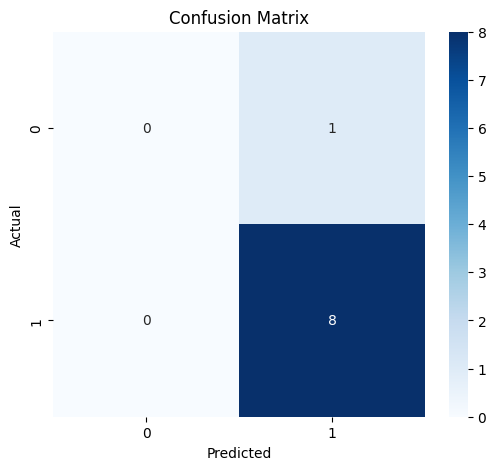

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [51]:
# Download
files.download(
    "confusion_matrix.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Service-wise Sentiment Analysis

In [52]:
service_sentiment = pd.crosstab(
    df["Service"],
    df["Sentiment"]
)

service_sentiment

Sentiment,Negative,Neutral,Positive
Service,,,
AI,0,0,12
Analytics,0,0,10
Cloud,0,0,12
Support,4,3,4


## Creating Service Sentiment Graph

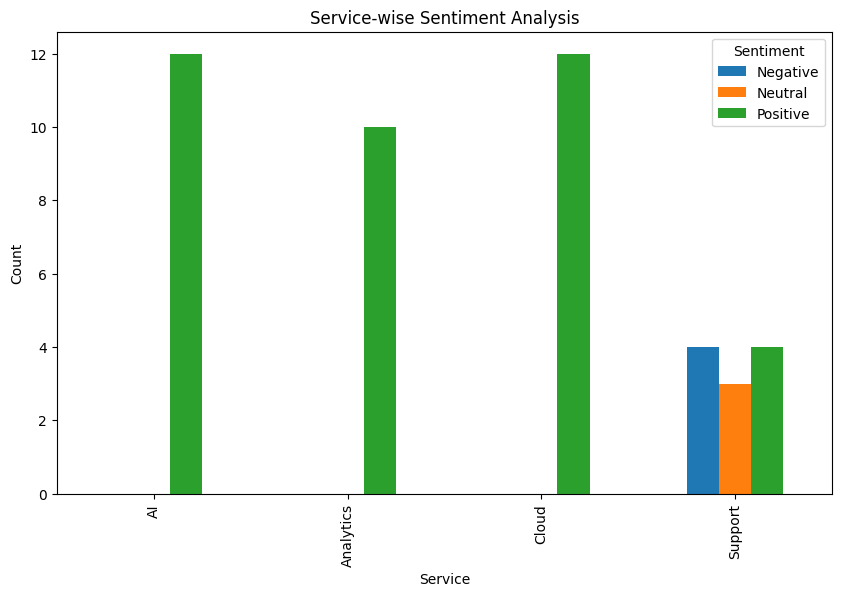

In [53]:
service_sentiment.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Service-wise Sentiment Analysis"
)

plt.ylabel(
    "Count"
)

plt.savefig(
    "service_sentiment.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [54]:
# Download
files.download(
    "service_sentiment.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Final Dataset Save

In [55]:
df.to_csv(
    "processed_feedback.csv",
    index=False
)

files.download(
    "processed_feedback.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Business Insights

• AI services received the highest positive feedback ratings.

• Cloud services demonstrated strong customer satisfaction and reliability.

• Support services generated most neutral and negative feedback.

• Analytics solutions consistently received positive customer responses.

• Naive Bayes achieved strong sentiment classification performance, indicating that customer feedback contains meaningful patterns for automated sentiment analysis.

## Conclusion

This project successfully implemented an end-to-end Natural Language Processing pipeline on customer feedback data. Text preprocessing techniques including cleaning, tokenization, stopword removal, and lemmatization were applied before transforming text into TF-IDF features. A Naive Bayes classifier was trained for sentiment classification and achieved strong performance. Multiple visualizations were generated to better understand customer feedback trends and sentiment distribution. The results demonstrate how NLP techniques can transform unstructured text into actionable business insights.